# Goal:
# 1) Count how many times each element appears in the database
#    and show a pie chart.
# 2) Train a GNN on materials containing the most frequent element,
#    and test on materials containing the second most frequent element,
#    reporting R^2, MSE, and a parity plot.

In [52]:
# -----------------------
# 0) Install dependencies
# -----------------------
!pip -q install torch-geometric
!pip -q install pandas numpy matplotlib scikit-learn tqdm

import math
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import requests
from torch.utils.data import DataLoader

from sklearn.metrics import r2_score, mean_squared_error

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import GINEConv, global_mean_pool

from typing import List, Dict, Tuple, Optional

In [53]:
# -----------------------
# 1) Reproducibility
# -----------------------
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [54]:
seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [55]:
# -----------------------
# 2) Data loading
# -----------------------
BASE = "https://aflow.org/API/aflux/"  # placeholder

SELECT = ",".join([
    "compound",
    "auid",
    "positions_fractional",
    "lattice_vectors",
    "spacegroup_relax",
    "agl_debye",
    "ael_debye_temperature",
    "agl_gruneisen",
    "agl_heat_capacity_Cv_300K",
    "agl_thermal_expansion_300K",
    "agl_thermal_conductivity_300K",
])

PER_PAGE = 500
MAX_PAGES = 2000

TARGET_KEY = "agl_thermal_conductivity_300K"

GLOBAL_FEATURE_KEYS = [
    "spacegroup_relax",
    "agl_debye",
    "ael_debye_temperature",
    "agl_gruneisen",
    "agl_heat_capacity_Cv_300K",
    "agl_thermal_expansion_300K",
]

POSITION_KEYS = ["positions_fractional", "positions_frac", "positions"]
LATTICE_KEYS  = ["lattice_vectors", "lattice", "cell"]
SPECIES_KEYS  = ["species", "elements", "atomic_symbols"]



In [56]:
KNN_K = 12
EDGE_EPS = 1e-8 #so 1/d+eps cannot be infinity

BATCH_SIZE = 32
EPOCHS = 50
LR = 1e-3
VAL_RATIO = 0.1
HIDDEN = 128
DEPTH = 3


In [57]:
BASE = "https://www.aflowlib.org/API/aflux/"

SELECT = (
    "$catalog(icsd),"
    "ael_debye_temperature(*),"
    "agl_debye(*),"
    "agl_acoustic_debye(*),"
    "agl_gruneisen(*),"
    "agl_heat_capacity_Cp_300K(*),"
    "agl_heat_capacity_Cv_300K(*),"
    "agl_thermal_conductivity_300K(*),"
    "agl_thermal_expansion_300K(*),"
    "agl_vibrational_entropy_300K_atom(*),"
    "positions_fractional(*),"
    "geometry(*),"
    "$format(json)"
)

PER_PAGE = 1000
MAX_PAGES = 10   # safety cap: 300k entries max; adjust if needed

session = requests.Session()
session.headers.update({"User-Agent": "colab-aflux-client/1.0"})

In [58]:
def fetch_page(page: int):
    """
    Fetch ONE page of AFLOW entries using aflux paging.

    Parameters
    ----------
    page : int
        Page index (1-based).

    Returns
    -------
    rows : list[dict]
        A list of AFLOW entries (JSON objects).
    url : str
        The exact URL used (for debugging / reproducibility).
    """
    url = f"{BASE}?{SELECT},$paging({page},{PER_PAGE})"

    r = session.get(url, timeout=120)
    r.raise_for_status()          # HTTP-level errors (404 / 500 / etc.)

    data = r.json()               # <-- AFLOW returns a LIST here
    if not isinstance(data, list):
        raise ValueError(
            f"Unexpected AFLOW response type: {type(data)}\nURL: {url}"
        )

    return data, url

In [59]:
def fetch_all_aflow(
    max_pages: int = MAX_PAGES,
    per_page: int = PER_PAGE,
):
    """
    Fetch all AFLOW entries using paging.
    Returns
    -------
    df : pd.DataFrame
    """
    all_rows = []
    last_url = None

    for page in tqdm(range(1, max_pages + 1), desc="Paging AFLOW"):
        rows, last_url = fetch_page(page)
        if len(rows) == 0:
            break
        all_rows.extend(rows)

    print(f"Fetched {len(all_rows)} entries.")
    print("Last URL:", last_url)
    return pd.DataFrame(all_rows)


In [60]:
df = fetch_all_aflow()


Paging AFLOW:  60%|██████    | 6/10 [00:09<00:06,  1.55s/it]

Fetched 5553 entries.
Last URL: https://www.aflowlib.org/API/aflux/?$catalog(icsd),ael_debye_temperature(*),agl_debye(*),agl_acoustic_debye(*),agl_gruneisen(*),agl_heat_capacity_Cp_300K(*),agl_heat_capacity_Cv_300K(*),agl_thermal_conductivity_300K(*),agl_thermal_expansion_300K(*),agl_vibrational_entropy_300K_atom(*),positions_fractional(*),geometry(*),$format(json),$paging(7,1000)


In [61]:
# ============================================================
# 3) Element parsing and counting
# ============================================================

# --- Parse chemical formula like "Al2O3", "Si", "Cu1Hf1Hg2"
#     Handles simple formulas without parentheses.
ELEMENT_RE = re.compile(r"([A-Z][a-z]?)(\d*\.?\d*)")

def parse_formula_simple(formula: str) -> dict:
    """
    Parse a simple chemical formula into element->count.
    Example: "Al2O3" -> {"Al":2, "O":3}
    If no number -> 1
    """
    if not isinstance(formula, str) or len(formula) == 0:
        return {}
    out = {}
    for (el, num) in ELEMENT_RE.findall(formula):
        if num == "" or num is None:
            c = 1.0
        else:
            c = float(num)
        out[el] = out.get(el, 0.0) + c
    return out

In [62]:
def count_elements_from_df(df: pd.DataFrame, formula_col="compound") -> pd.Series:
    """
    Count total occurrences of each element (sum of stoichiometric coefficients)
    across the entire dataset.
    """
    counts = {}
    for f in df[formula_col].astype(str).tolist():
        comp = parse_formula_simple(f)
        for el, c in comp.items():
            counts[el] = counts.get(el, 0.0) + float(c)
    s = pd.Series(counts).sort_values(ascending=False)
    return s

elem_counts = count_elements_from_df(df, formula_col="compound")
print("Top 20 elements by total stoichiometric count:")
print(elem_counts.head(20))


Top 20 elements by total stoichiometric count:
O     4618.0
Si    2252.0
Al    2027.0
Ge    1820.0
S     1468.0
C     1351.0
Sn    1338.0
Ni    1262.0
B     1213.0
Sb    1199.0
Pd    1193.0
P     1155.0
Rh    1136.0
Zr    1118.0
N     1117.0
Pt    1110.0
Mg     925.0
Se     900.0
Be     898.0
Ir     889.0
dtype: float64


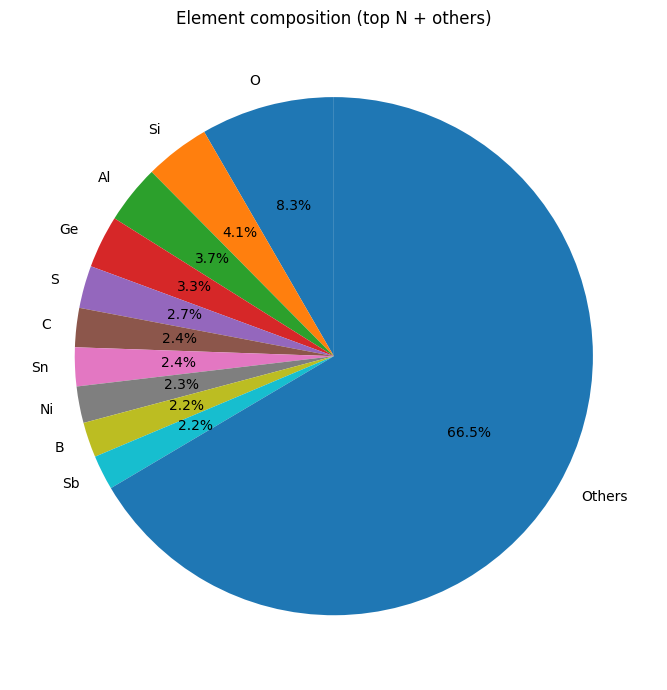

Most frequent element: O
2nd most frequent element: Si


In [63]:
# -----------------------
# 3.1) Pie chart (Top N + Others)
# -----------------------
def pie_top_elements(elem_counts: pd.Series, top_n=10, title="Element composition (top N + others)"):
    top = elem_counts.head(top_n)
    others = elem_counts.iloc[top_n:].sum()
    labels = list(top.index) + (["Others"] if others > 0 else [])
    sizes  = list(top.values) + ([others] if others > 0 else [])
    plt.figure(figsize=(7,7))
    plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
    plt.title(title)
    plt.tight_layout()
    plt.show()

pie_top_elements(elem_counts, top_n=10)

top1_el = elem_counts.index[0]
top2_el = elem_counts.index[1] if len(elem_counts) > 1 else None
print("Most frequent element:", top1_el)
print("2nd most frequent element:", top2_el)

In [64]:
# ============================================================
# 4) Filter dataframe by "contains element"
# ============================================================

def contains_element(formula: str, element: str) -> bool:
    comp = parse_formula_simple(formula)
    return element in comp and comp[element] > 0

df_top1 = df[df["compound"].astype(str).apply(lambda x: contains_element(x, top1_el))].copy()
df_top2 = df[df["compound"].astype(str).apply(lambda x: contains_element(x, top2_el))].copy() if top2_el else pd.DataFrame()

# Prefer making test set EXCLUSIVE (top2 but not top1) to avoid leakage.
if top2_el is not None:
    df_top2_excl = df_top2[~df_top2["compound"].astype(str).apply(lambda x: contains_element(x, top1_el))].copy()
    if len(df_top2_excl) < 50:
        print(f"[Warn] Exclusive test set (contains {top2_el} but not {top1_el}) is small: {len(df_top2_excl)}.")
        print("       Falling back to all materials containing the 2nd element.")
        df_test = df_top2
    else:
        df_test = df_top2_excl
else:
    df_test = pd.DataFrame()

print("Train pool size (contains top element):", len(df_top1))
print("Test pool size  (contains 2nd element):", len(df_test))


Train pool size (contains top element): 598
Test pool size  (contains 2nd element): 418


In [65]:
# ============================================================
# 5) Graph building
# ============================================================
TARGET_KEY = "agl_thermal_conductivity_300K"
PERIODIC_TABLE = {
    "H": (1, 1.008), "He": (2, 4.002602), "Li": (3, 6.94), "Be": (4, 9.0121831),
    "B": (5, 10.81), "C": (6, 12.011), "N": (7, 14.007), "O": (8, 15.999),
    "F": (9, 18.998403163), "Ne": (10, 20.1797), "Na": (11, 22.98976928), "Mg": (12, 24.305),
    "Al": (13, 26.9815385), "Si": (14, 28.085), "P": (15, 30.973761998), "S": (16, 32.06),
    "Cl": (17, 35.45), "Ar": (18, 39.948), "K": (19, 39.0983), "Ca": (20, 40.078),
    "Sc": (21, 44.955908), "Ti": (22, 47.867), "V": (23, 50.9415), "Cr": (24, 51.9961),
    "Mn": (25, 54.938044), "Fe": (26, 55.845), "Co": (27, 58.933194), "Ni": (28, 58.6934),
    "Cu": (29, 63.546), "Zn": (30, 65.38), "Ga": (31, 69.723), "Ge": (32, 72.63),
    "As": (33, 74.921595), "Se": (34, 78.971), "Br": (35, 79.904), "Kr": (36, 83.798),
    "Rb": (37, 85.4678), "Sr": (38, 87.62), "Y": (39, 88.90584), "Zr": (40, 91.224),
    "Nb": (41, 92.90637), "Mo": (42, 95.95), "Tc": (43, 98.0), "Ru": (44, 101.07),
    "Rh": (45, 102.9055), "Pd": (46, 106.42), "Ag": (47, 107.8682), "Cd": (48, 112.414),
    "In": (49, 114.818), "Sn": (50, 118.71), "Sb": (51, 121.76), "Te": (52, 127.6),
    "I": (53, 126.90447), "Xe": (54, 131.293), "Cs": (55, 132.90545196), "Ba": (56, 137.327),
    "La": (57, 138.90547), "Ce": (58, 140.116), "Pr": (59, 140.90766), "Nd": (60, 144.242),
    "Pm": (61, 145.0), "Sm": (62, 150.36), "Eu": (63, 151.964), "Gd": (64, 157.25),
    "Tb": (65, 158.92535), "Dy": (66, 162.5), "Ho": (67, 164.93033), "Er": (68, 167.259),
    "Tm": (69, 168.93422), "Yb": (70, 173.045), "Lu": (71, 174.9668), "Hf": (72, 178.49),
    "Ta": (73, 180.94788), "W": (74, 183.84), "Re": (75, 186.207), "Os": (76, 190.23),
    "Ir": (77, 192.217), "Pt": (78, 195.084), "Au": (79, 196.966569), "Hg": (80, 200.592),
    "Tl": (81, 204.38), "Pb": (82, 207.2), "Bi": (83, 208.9804), "Po": (84, 209.0),
    "At": (85, 210.0), "Rn": (86, 222.0), "Fr": (87, 223.0), "Ra": (88, 226.0),
    "Ac": (89, 227.0), "Th": (90, 232.0377), "Pa": (91, 231.03588), "U": (92, 238.02891),
    "Np": (93, 237.0), "Pu": (94, 244.0), "Am": (95, 243.0), "Cm": (96, 247.0),
    "Bk": (97, 247.0), "Cf": (98, 251.0), "Es": (99, 252.0), "Fm": (100, 257.0),
    "Md": (101, 258.0), "No": (102, 259.0), "Lr": (103, 266.0), "Rf": (104, 267.0),
    "Db": (105, 268.0), "Sg": (106, 269.0), "Bh": (107, 270.0), "Hs": (108, 277.0),
    "Mt": (109, 278.0), "Ds": (110, 281.0), "Rg": (111, 282.0), "Cn": (112, 285.0),
    "Nh": (113, 286.0), "Fl": (114, 289.0), "Mc": (115, 290.0), "Lv": (116, 293.0),
    "Ts": (117, 294.0), "Og": (118, 294.0),
}



In [66]:
TARGET_KEY = "agl_thermal_conductivity_300K"
POS_KEY    = "positions_fractional"
LAT_KEY    = "lattice_vectors"

GLOBAL_FEATURE_KEYS = [
    "agl_debye",
    "ael_debye_temperature",
    "agl_gruneisen",
    "agl_heat_capacity_Cv_300K",
    "agl_thermal_expansion_300K",
]

EDGE_EPS = 1e-6


In [67]:
def parse_formula(formula: str):
    '''
    Simple regex formula parser (no parentheses).
    Returns expanded elements list and counts dict.
    '''
    tokens = re.findall(r"([A-Z][a-z]?)(\d*)", str(formula))
    counts = {}
    expanded = []
    for sym, num in tokens:
        n = int(num) if num else 1
        counts[sym] = counts.get(sym, 0) + n
        expanded.extend([sym] * n)
    return expanded, counts

In [68]:
def assign_masses(compound: str):
    '''
    Expand formula into per-atom Z and mass lists.
    '''
    elems, _ = parse_formula(compound)
    masses, Zs = [], []
    for sym in elems:
        Z, m = PERIODIC_TABLE[sym]
        Zs.append(int(Z))
        masses.append(float(m))
    return masses, Zs

In [69]:
def _wrap_frac_delta(df: np.ndarray):
    '''Wrap fractional coordinate delta into [-0.5, 0.5] for minimum-image convention.'''
    return df - np.round(df)

def pbc_distance_matrix(frac: np.ndarray, lattice: np.ndarray) -> np.ndarray:
    """
    Compute PBC pairwise distances.
    frac: (N,3) fractional positions
    lattice: (3,3) lattice vectors
    returns D: (N,N) distances, with diagonal = inf
    """
    # pairwise fractional deltas: (N,N,3)
    dfrac = frac[None, :, :] - frac[:, None, :]
    dfrac = _wrap_frac_delta(dfrac)                 # minimum-image
    dcart = dfrac @ lattice                         # (N,N,3)
    D = np.linalg.norm(dcart, axis=-1)              # (N,N)
    np.fill_diagonal(D, np.inf)
    return D

def assign_edges_knn(frac: np.ndarray, lattice: np.ndarray, k: int = 12):
    """
    Build directed kNN edges under PBC.
    returns edge_index (2,E) torch.LongTensor, dist_list (E,) np.ndarray
    """
    D = pbc_distance_matrix(frac, lattice)
    N = D.shape[0]
    src, dst, dist = [], [], []
    for i in range(N):
        nn = np.argsort(D[i])[:k]
        for j in nn:
            src.append(i)
            dst.append(int(j))
            dist.append(float(D[i, j]))
    edge_index = torch.tensor([src, dst], dtype=torch.long)
    dist_list = np.array(dist, dtype=float)
    return edge_index, dist_list

def assign_edge_attributes(dist_list: np.ndarray, eps: float = EDGE_EPS) -> torch.Tensor:
    """Edge features: [d, 1/(d+eps)]"""
    d = dist_list.astype(np.float32)
    inv = (1.0 / (d + eps)).astype(np.float32)
    return torch.tensor(np.stack([d, inv], axis=1), dtype=torch.float32)

def assign_global_attributes(entry: dict, keys: list[str]) -> torch.Tensor:
    """Global features vector u: shape (u_dim,) -> caller will reshape to (1,u_dim)."""
    vals = []
    for k in keys:
        v = entry.get(k, np.nan)
        v = float(v)
        if not np.isfinite(v):
            # choose a policy: either raise or impute
            # here: raise, because NaNs silently break training
            raise ValueError(f"Global feature {k} is NaN/inf")
        vals.append(v)
    return torch.tensor(vals, dtype=torch.float32)

In [70]:
def build_graph_from_entry(entry: dict, k: int = 12) -> Data:
    """
    Build one PyG graph using your columns:
      - positions_fractional
      - lattice_vectors
      - compound (for node features via assign_masses)
      - global features keys above
      - target agl_thermal_conductivity_300K -> y=log1p(kappa)
    """
    # ---- positions + lattice ----
    frac = np.array(entry[POS_KEY], dtype=float)
    if frac.ndim != 2 or frac.shape[1] != 3:
        raise ValueError(f"{POS_KEY} has invalid shape {frac.shape}")

    lattice = np.array(entry[LAT_KEY], dtype=float)
    if lattice.shape != (3, 3):
        raise ValueError(f"{LAT_KEY} must be (3,3), got {lattice.shape}")

    # ---- node features from compound (fallback) ----
    compound = entry.get("compound", None)
    if compound is None:
        raise KeyError("Missing compound")
    masses, Zs = assign_masses(compound)  # from your existing notebook
    if len(masses) != frac.shape[0]:
        raise ValueError(
            f"Expanded atoms from compound ({len(masses)}) != number of positions ({frac.shape[0]}). "
            f"Need per-site species to avoid this."
        )
    x = torch.tensor(np.stack([Zs, masses], axis=1), dtype=torch.float32)  # (N,2)

    # ---- edges ----
    edge_index, dist_list = assign_edges_knn(frac, lattice, k=k)
    edge_attr = assign_edge_attributes(dist_list, eps=EDGE_EPS)           # (E,2)

    # ---- global u ----
    u = assign_global_attributes(entry, GLOBAL_FEATURE_KEYS).view(1, -1)  # (1,u_dim)

    # ---- target ----
    y_raw = entry.get(TARGET_KEY, None)
    if y_raw is None:
        raise ValueError(f"Missing target {TARGET_KEY}")
    kappa = float(y_raw)
    if not np.isfinite(kappa) or kappa <= 0:
        raise ValueError(f"Invalid target {TARGET_KEY}={y_raw}")
    y = torch.tensor([[math.log1p(kappa)]], dtype=torch.float32)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, u=u, y=y)
    data.compound = str(compound)
    data.auid = str(entry.get("auid", ""))
    return data

In [71]:
def df_to_graphs(df: pd.DataFrame, k: int = 12, limit=None):
    graphs, skipped = [], []
    n = len(df) if limit is None else min(len(df), limit)
    for i in tqdm(range(n), desc="Building graphs"):
        entry = df.iloc[i].to_dict()
        try:
            graphs.append(build_graph_from_entry(entry, k=k))
        except Exception as e:
            skipped.append((i, str(e)))
    print(f"Built graphs: {len(graphs)} / {n}, skipped: {len(skipped)}")
    if len(skipped) > 0:
        print("Example skip:", skipped[0])
    return graphs, skipped

In [72]:
# Build graphs for train pool and test pool
KNN_K = 12
train_graphs_all, sk1 = df_to_graphs(df_top1, k=KNN_K)
test_graphs, sk2 = df_to_graphs(df_test, k=KNN_K)

assert len(train_graphs_all) > 200, "Train pool too small after graph building."
assert len(test_graphs) > 50, "Test pool too small after graph building."

Building graphs: 100%|██████████| 598/598 [00:00<00:00, 5838.34it/s]


Built graphs: 0 / 598, skipped: 598
Example skip: (0, "'lattice_vectors'")


Building graphs: 100%|██████████| 418/418 [00:00<00:00, 6342.82it/s]

Built graphs: 0 / 418, skipped: 418
Example skip: (0, "'lattice_vectors'")


AssertionError: Train pool too small after graph building.

In [73]:
[c for c in df.columns if "edge" in c.lower()]

[]